# Fabric Defect Classification — ResNet18 (Main Model)

**Notebook 04** of the fabric defect classification pipeline.

Notebook 03 trained a small network from scratch and reached **0.583 macro F1**. It learned the common classes well but struggled badly with several defect types, and its held-out score stopped improving after about five epochs — a sign it had reached the limit of what 2,737 images can teach a network starting from nothing.

This notebook takes a different approach: **transfer learning**.

### What transfer learning means

ResNet18 has already been trained on ImageNet, a collection of over a million photographs. In learning to tell apart a thousand everyday objects, it built up general visual skills — detecting edges, textures, repeating patterns, breaks in a surface. Those skills are not specific to cats or cars; they apply to fabric too.

So instead of starting from random numbers, we start from that trained network and adapt it to our nine classes. The model no longer has to learn what an edge looks like from 27 examples of "Vertical" — it already knows, and only has to learn which patterns mean which defect.

### What this notebook does

1. Compares **three different ways** of adapting ResNet18, and records the results
2. Picks the best one based on validation performance
3. Trains that version across all five folds
4. Saves the trained models so they can be reused without retraining
5. Compares the result against the baseline CNN from Notebook 03

Everything else stays identical to Notebook 03 — the same folds, the same augmentation, the same metrics — so the comparison is fair and any difference comes from the model rather than the setup.

## 1. Setup

**What:** Load the libraries, find the cleaned data, and set the configuration.

**Why:** Using the same folds and the same random seed as Notebook 03 is what makes the comparison meaningful. If the two models were tested on different splits, any difference between them could just be luck.

In [1]:
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             recall_score)
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

MODEL_NAME = "resnet18"
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
NUM_WORKERS = 2
N_FOLDS = 5

EXP_EPOCHS = 15      # epochs while comparing approaches
FINAL_EPOCHS = 25    # epochs for the chosen approach (matches Notebook 03)

BASELINE = {"macro_f1": 0.583, "accuracy": 0.837}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

CANDIDATES = [Path("/content/data/processed"), Path("/kaggle/working/processed")]
kaggle_input = Path("/kaggle/input")
if kaggle_input.exists():
    CANDIDATES += sorted(kaggle_input.glob("*/processed"))
    CANDIDATES += sorted(kaggle_input.glob("*"))
CANDIDATES.append(Path("data/processed"))
DATA_DIR = next((c for c in CANDIDATES if (c / "manifest.csv").exists()), None)

if Path("/kaggle/working").exists():
    ROOT = Path("/kaggle/working")
elif Path("/content").exists():
    ROOT = Path("/content")
else:
    ROOT = Path(".")

RESULTS_DIR = ROOT / "outputs" / MODEL_NAME
MODELS_DIR = ROOT / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")

print("Device  :", device)
print("Results :", RESULTS_DIR)
print("Models  :", MODELS_DIR)
print("Data    :", DATA_DIR if DATA_DIR else "not found - the next cell rebuilds it")

Device  : cuda
Results : /content/outputs/resnet18
Models  : /content/models
Data    : not found - the next cell rebuilds it


### If the cleaned data is missing

Seeing `Data : not found` is normal rather than an error. Colab and Kaggle give every notebook its own machine, so this one cannot see the files Notebook 02 wrote.

The cell below rebuilds the dataset from the raw images, repeating exactly what Notebook 02 did — the same duplicate removal, the same 224×224 conversion, the same random seed. The folds come out identical, so results stay comparable. It takes about five minutes.

In [2]:
if DATA_DIR is None:
    import hashlib
    import os
    import shutil
    from collections import Counter

    from sklearn.model_selection import StratifiedKFold

    print("Rebuilding the cleaned dataset from the raw images.\n")

    ds2 = "/kaggle/input/multi-class-fabric-defect-detection-dataset/Dataset"
    if not os.path.exists(ds2):
        import kagglehub
        ds2 = os.path.join(
            kagglehub.dataset_download("ziya07/multi-class-fabric-defect-detection-dataset"),
            "Dataset")
    raw_classes = sorted(os.listdir(ds2))

    def dhash(path, size=16):
        with Image.open(path) as img:
            small = img.convert("L").resize((size + 1, size), Image.BILINEAR)
        px = list(small.getdata())
        bits = []
        for row in range(size):
            for col in range(size):
                bits.append("1" if px[row * (size + 1) + col] > px[row * (size + 1) + col + 1] else "0")
        return "".join(bits)

    candidates = [(c, p) for c in raw_classes
                  for p in sorted((Path(ds2) / c).glob("*")) if "_processed" not in p.name]
    print(f"After removing _processed     : {len(candidates)}")

    seen, after_exact = set(), []
    for c, p in candidates:
        h = hashlib.md5(p.read_bytes()).hexdigest()
        if h not in seen:
            seen.add(h)
            after_exact.append((c, p))
    print(f"After removing exact copies   : {len(after_exact)}")

    seen2, keep = set(), []
    for c, p in after_exact:
        k = (c, dhash(p))
        if k not in seen2:
            seen2.add(k)
            keep.append((c, p))
    print(f"After removing near-duplicates: {len(keep)}")

    labels = [c for c, _ in keep]
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_of = {}
    for f, (_, te) in enumerate(skf.split(range(len(keep)), labels)):
        for i in te:
            fold_of[i] = f

    OUT = ROOT / "data" / "processed"
    if OUT.exists():
        shutil.rmtree(OUT)
    (OUT / "images").mkdir(parents=True)

    rows = []
    for i, (c, p) in enumerate(keep):
        d = OUT / "images" / c
        d.mkdir(exist_ok=True)
        name = f"{i:05d}.jpg"
        with Image.open(p) as im:
            im.convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR).save(d / name, quality=95)
        rows.append({"filepath": str(Path("images") / c / name), "class": c,
                     "fold": fold_of[i], "source_file": p.name})
    pd.DataFrame(rows).to_csv(OUT / "manifest.csv", index=False)

    counts = Counter(labels)
    weights = {c: len(labels) / (len(raw_classes) * counts[c]) for c in raw_classes}
    json.dump(weights, open(OUT / "class_weights.json", "w"), indent=2)

    DATA_DIR = OUT
    print("\nRebuilt at:", DATA_DIR)
else:
    print("Using the cleaned data at:", DATA_DIR)

Rebuilding the cleaned dataset from the raw images.

Using Colab cache for faster access to the 'multi-class-fabric-defect-detection-dataset' dataset.
After removing _processed     : 2758
After removing exact copies   : 2741
After removing near-duplicates: 2737

Rebuilt at: /content/data/processed


In [3]:
manifest = pd.read_csv(DATA_DIR / "manifest.csv")
class_weights_raw = json.load(open(DATA_DIR / "class_weights.json"))
class_names = sorted(manifest["class"].unique())
n_classes = len(class_names)
cls_to_idx = {c: i for i, c in enumerate(class_names)}

for p in (ROOT / "outputs" / "baseline_cnn" / "baseline_cnn_summary.json",
          Path("outputs/baseline_cnn/baseline_cnn_summary.json")):
    if p.exists():
        s = json.load(open(p))
        BASELINE = {"macro_f1": s["macro_f1"], "accuracy": s["accuracy"]}
        print("Loaded baseline results from", p)
        break
else:
    print("Using the baseline figures recorded in the configuration above.")

print(f"\nImages : {len(manifest)}  |  Classes: {n_classes}  |  Folds: {manifest['fold'].nunique()}")
print(f"Baseline CNN to beat: macro F1 {BASELINE['macro_f1']:.3f}, accuracy {BASELINE['accuracy']:.3f}")

Using the baseline figures recorded in the configuration above.

Images : 2737  |  Classes: 9  |  Folds: 5
Baseline CNN to beat: macro F1 0.583, accuracy 0.837


**Observations:** All 2,737 images loaded, in 9 classes and 5 folds — the same data and the same folds Notebook 03 used, so the two models can be compared directly.

The baseline figures to beat are **0.583 macro F1** and **0.837 accuracy**.

## 2. The Data Pipeline

**What:** Set up image loading and augmentation, exactly as in Notebook 03.

**Why:** For the comparison to be fair, only *one* thing may change between the two notebooks: the model. If ResNet18 also received different augmentation or different normalisation, we could not tell which change caused any improvement.

Two details are worth restating. **No 90° rotations** — turning an image a quarter turn would change a "Vertical" defect into a "horizontal" one while the label stayed the same, creating deliberately wrong training data. And the **normalisation values** are ImageNet's, which matters more here than it did in Notebook 03: ResNet18 was originally trained on images scaled this exact way, so feeding it anything else would waste part of what it already knows.

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),          # small angles only - see note above
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class FabricDataset(Dataset):
    def __init__(self, df, root, transform):
        self.df = df.reset_index(drop=True)
        self.root = Path(root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(self.root / row["filepath"]).convert("RGB")
        return self.transform(img), cls_to_idx[row["class"]]

def make_loader(df, transform, shuffle):
    return DataLoader(FabricDataset(df, DATA_DIR, transform), batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=NUM_WORKERS)

print("Pipeline ready - identical to Notebook 03.")

Pipeline ready - identical to Notebook 03.


## 3. Building ResNet18

**What:** Load ResNet18 with its ImageNet training already in place, and replace its final layer.

**Why replace the last layer?** The original network ends with a layer that produces 1,000 numbers, one per ImageNet category. We need 9, one per fabric class, so that final layer is swapped for a new one. Everything before it — the part that actually recognises edges, textures and patterns — is kept.

**Two ways to train it, and we will test both:**

- **Frozen backbone.** Lock every layer except the new final one. The network becomes a fixed feature extractor and we only learn how to combine what it already sees. Fast, and with only 2,737 images there is little to overfit, but the features stay generic and were never tuned for fabric.
- **Full fine-tuning.** Let every layer keep learning, usually at a small learning rate so the existing knowledge is refined rather than destroyed. Slower and riskier on a small dataset, but the features can adapt to fabric texture specifically.

There is no way to know in advance which wins on this dataset, which is exactly why §5 measures it instead of guessing.

In [5]:
def build_resnet18(n_classes, freeze_backbone=False):
    try:
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    except AttributeError:
        model = models.resnet18(pretrained=True)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model

for frozen in (True, False):
    m = build_resnet18(n_classes, freeze_backbone=frozen)
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    label = "frozen backbone" if frozen else "full fine-tuning"
    print(f"{label:18s} total {total:,}  trainable {trainable:,}  ({trainable/total:.1%})")

print(f"\nBaseline CNN from Notebook 03 had 391,689 parameters in total.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 213MB/s]


frozen backbone    total 11,181,129  trainable 4,617  (0.0%)
full fine-tuning   total 11,181,129  trainable 11,181,129  (100.0%)

Baseline CNN from Notebook 03 had 391,689 parameters in total.


**Observations:** ResNet18 has **11,181,129 parameters** — about **28 times** more than the baseline CNN's 391,689.

Normally a network that large would be hopeless on 2,737 images; it could memorise them many times over. Transfer learning is what makes it workable, because those parameters are not starting from random numbers. They already hold what the network learned from a million photographs, and training only has to adjust them.

The two settings differ enormously in how much actually changes:

- **Frozen backbone:** only **4,617** parameters train — the new final layer alone, or 0.0% of the network. Everything else is locked.
- **Full fine-tuning:** all 11,181,129 train.

Which of these works better on fabric is not obvious, which is why §5 measures it.

## 4. The Training Routine

**What:** One function that trains a model and reports how it does on held-out images.

**Why the same class weights again?** Notebook 02 calculated a weight for every class based on how rare it is, and Notebook 03 used them. Getting a "Vertical" image wrong costs about 62 times as much as getting a "defect free" image wrong. Keeping this identical means the two models are being asked to solve the same problem.

In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, preds, trues = 0.0, [], []
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            preds.append(out.argmax(1).cpu())
            trues.append(y.cpu())

    return (total_loss / len(loader.dataset),
            torch.cat(preds).numpy(),
            torch.cat(trues).numpy())

def train_model(train_df, eval_df, freeze, lr, epochs, seed=SEED, verbose=True):
    torch.manual_seed(seed)
    model = build_resnet18(n_classes, freeze_backbone=freeze).to(device)

    weights = torch.tensor([class_weights_raw[c] for c in class_names],
                           dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr)

    train_loader = make_loader(train_df, train_tf, shuffle=True)
    eval_loader = make_loader(eval_df, eval_tf, shuffle=False)

    history = []
    for epoch in range(1, epochs + 1):
        tr_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        ev_loss, ev_pred, ev_true = run_epoch(model, eval_loader, criterion)
        ev_f1 = f1_score(ev_true, ev_pred, average="macro", zero_division=0)
        history.append({"epoch": epoch, "train_loss": tr_loss,
                        "eval_loss": ev_loss, "eval_f1": ev_f1})
        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"    epoch {epoch:2d}/{epochs}  train loss {tr_loss:.3f}  "
                  f"| held-out loss {ev_loss:.3f} f1 {ev_f1:.3f}")

    return model, pd.DataFrame(history), ev_pred, ev_true

print("Training routine defined.")

Training routine defined.


## 5. Comparing Three Approaches

**What:** Train three versions of ResNet18 and compare them on a validation set.

**Why a separate validation set?** We need to choose between approaches, and that choice has to be made using data that is *not* used for the final score. Otherwise we would be picking whichever setup happened to look best on the test data, and the reported result would be flattering rather than honest.

So the folds are used like this:

| Folds | Role |
|---|---|
| 0, 1, 2 | Training |
| 3 | Validation — used to choose the approach |
| 4 | Untouched during this step |

**The three approaches:**

| Name | Setup | Question it answers |
|---|---|---|
| `frozen_backbone` | Only the new final layer learns, lr 0.001 | Are ImageNet's ready-made features enough on their own? |
| `finetune_lr1e-4` | Every layer learns, small lr 0.0001 | Does gently adapting the features to fabric help? |
| `finetune_lr1e-3` | Every layer learns, larger lr 0.001 | Does a larger step damage what the network already knows? |

The third exists to test a real risk: fine-tuning a pretrained network with too large a learning rate can overwrite its knowledge in the first few batches, leaving it no better than training from scratch.

Every run is appended to an experiment log so the whole comparison is recorded rather than remembered.

In [8]:
EXPERIMENTS = [
    {"name": "frozen_backbone", "freeze": True,  "lr": 1e-3},
    {"name": "finetune_lr1e-4", "freeze": False, "lr": 1e-4},
    {"name": "finetune_lr1e-3", "freeze": False, "lr": 1e-3},
]

train_df = manifest[manifest["fold"].isin([0, 1, 2])]
val_df = manifest[manifest["fold"] == 3]
print(f"Train: {len(train_df)} images   Validation: {len(val_df)} images\n")

exp_log, exp_histories = [], {}
start_all = time.time()

for cfg in EXPERIMENTS:
    print(f"--- {cfg['name']} (freeze={cfg['freeze']}, lr={cfg['lr']}) ---")
    t0 = time.time()
    _, hist, pred, true = train_model(
        train_df, val_df, cfg["freeze"], cfg["lr"], EXP_EPOCHS)
    mins = (time.time() - t0) / 60

    val_f1 = f1_score(true, pred, average="macro", zero_division=0)
    val_acc = (pred == true).mean()
    exp_log.append({**cfg, "epochs": EXP_EPOCHS, "val_macro_f1": val_f1,
                    "val_accuracy": val_acc, "minutes": round(mins, 1)})
    exp_histories[cfg["name"]] = hist
    print(f"  -> validation macro F1 {val_f1:.3f} | accuracy {val_acc:.3f} "
          f"| {mins:.1f} min\n")

exp_df = pd.DataFrame(exp_log).sort_values("val_macro_f1", ascending=False)
exp_df.to_csv(RESULTS_DIR / f"{MODEL_NAME}_experiments.csv", index=False)

print(f"Total: {(time.time() - start_all)/60:.1f} minutes\n")
print(exp_df.to_string(index=False))

Train: 1643 images   Validation: 547 images

--- frozen_backbone (freeze=True, lr=0.001) ---
    epoch  1/15  train loss 1.762  | held-out loss 0.984 f1 0.429
    epoch  5/15  train loss 0.810  | held-out loss 0.477 f1 0.677
    epoch 10/15  train loss 0.669  | held-out loss 0.453 f1 0.678
    epoch 15/15  train loss 0.609  | held-out loss 0.370 f1 0.711
  -> validation macro F1 0.711 | accuracy 0.912 | 2.8 min

--- finetune_lr1e-4 (freeze=False, lr=0.0001) ---
    epoch  1/15  train loss 1.172  | held-out loss 0.646 f1 0.572
    epoch  5/15  train loss 0.411  | held-out loss 0.315 f1 0.801
    epoch 10/15  train loss 0.194  | held-out loss 0.126 f1 0.911
    epoch 15/15  train loss 0.179  | held-out loss 0.208 f1 0.908
  -> validation macro F1 0.908 | accuracy 0.958 | 3.0 min

--- finetune_lr1e-3 (freeze=False, lr=0.001) ---
    epoch  1/15  train loss 1.473  | held-out loss 0.854 f1 0.457
    epoch  5/15  train loss 1.052  | held-out loss 0.511 f1 0.476
    epoch 10/15  train loss 0.

**Observations:** The three approaches came out very far apart.

| Approach | Validation macro F1 |
|---|---|
| **finetune_lr1e-4** | **0.908** |
| frozen_backbone | 0.711 |
| finetune_lr1e-3 | 0.502 |

**Gentle fine-tuning wins clearly**, beating the frozen version by 0.197. So ImageNet's ready-made features are useful on their own — 0.711 already beats the baseline CNN's 0.583 — but letting them adapt to fabric specifically is worth much more.

**The large learning rate did exactly the damage we expected.** At 0.001 the model scored 0.502, which is *worse than the baseline CNN trained from scratch*. Taking steps that big in the first few batches overwrites what the network learned from ImageNet, so it ends up with damaged features and no time to relearn them. This is why the third approach was included: it shows the chosen learning rate is right for a reason, not just because it happened to be picked.

All three took about the same time — under 3 minutes each — so the differences are entirely down to the setup rather than the training budget.

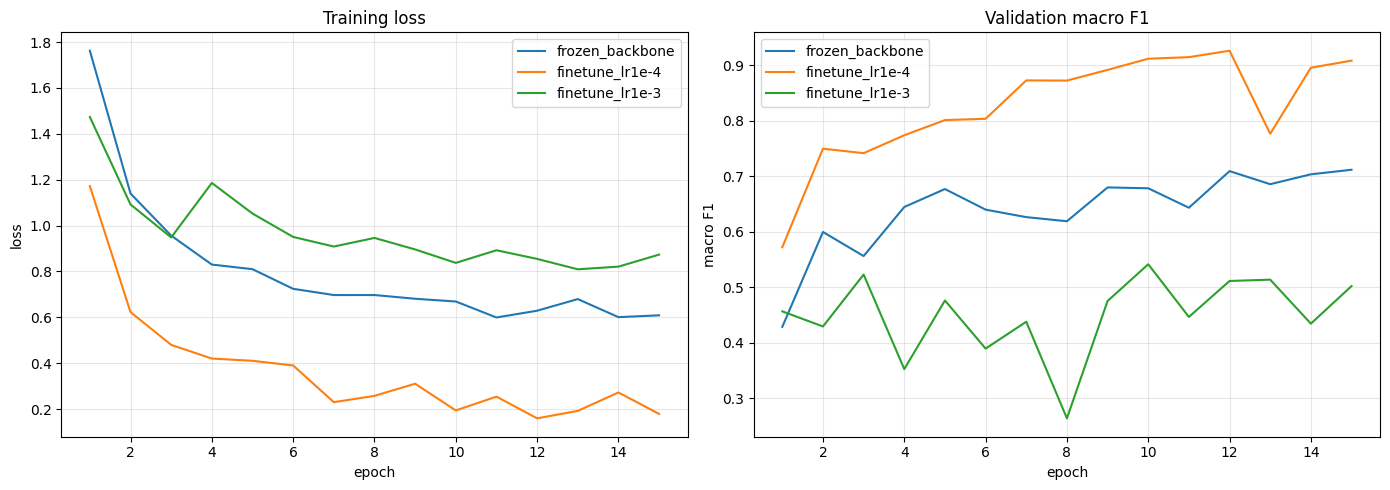

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in exp_histories.items():
    axes[0].plot(hist["epoch"], hist["train_loss"], label=name)
    axes[1].plot(hist["epoch"], hist["eval_f1"], label=name)

axes[0].set_title("Training loss"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[1].set_title("Validation macro F1"); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro F1")
for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{MODEL_NAME}_experiments.png", dpi=150, bbox_inches="tight")
plt.show()

**Observations:** The three curves behave in three completely different ways.

**finetune_lr1e-4** drops fastest and furthest. Its training loss falls from 1.17 to 0.18, and its validation score reaches 0.91 by epoch 10 and then holds steady. It learns quickly and then stops improving because it has little left to fix.

**frozen_backbone** improves steadily but levels off around 0.68–0.71. Its training loss never drops below 0.61 — with only the final layer able to change, there is a limit to how well it can fit fabric, no matter how long it trains.

**finetune_lr1e-3** never really learns. Its training loss stays high (0.87) and its validation score wanders between 0.46 and 0.54 without a trend. This is the signature of a model whose useful starting point has been destroyed — it is effectively learning from scratch, but with a network far too large for 2,737 images.

## 6. Training the Chosen Approach on All Five Folds

**What:** Take the approach that scored best on validation and train it five times, holding out a different fold each time.

**Why:** This is the same procedure Notebook 03 used, so the two results can be compared directly. Every image ends up with a prediction from a model that never saw it during training, which matters most for "Vertical" — all 27 of its images get tested rather than roughly 4.

**One caveat, stated openly.** The approach was chosen using fold 3, and fold 3 also appears in this cross-validation. That makes the final number very slightly optimistic. Fold 4 was never involved in the choice, so its score is a clean check: if it broadly matches the others, the selection did not distort the result.

Each fold's trained weights are saved, so predictions can be made later without repeating any of this.

In [10]:
best = exp_df.iloc[0]
BEST_CFG = {"freeze": bool(best["freeze"]), "lr": float(best["lr"])}
print(f"Chosen approach: {best['name']}  (freeze={BEST_CFG['freeze']}, lr={BEST_CFG['lr']})")
print(f"Validation macro F1 was {best['val_macro_f1']:.3f}\n")

oof_pred = np.zeros(len(manifest), dtype=int)
oof_true = np.zeros(len(manifest), dtype=int)
fold_scores, histories = [], []

start = time.time()
for fold in sorted(manifest["fold"].unique()):
    print(f"Fold {fold}")
    tr = manifest[manifest["fold"] != fold]
    te = manifest[manifest["fold"] == fold]

    model, hist, pred, true = train_model(
        tr, te, BEST_CFG["freeze"], BEST_CFG["lr"], FINAL_EPOCHS, seed=SEED + fold)

    idx = te.index.values
    oof_pred[idx] = pred
    oof_true[idx] = true
    hist["fold"] = fold
    histories.append(hist)

    f1 = f1_score(true, pred, average="macro", zero_division=0)
    acc = (pred == true).mean()
    fold_scores.append({"fold": fold, "macro_f1": f1, "accuracy": acc})

    torch.save(model.state_dict(), MODELS_DIR / f"{MODEL_NAME}_fold{fold}.pt")
    print(f"  -> macro F1 {f1:.3f} | accuracy {acc:.3f} | weights saved\n")

history_df = pd.concat(histories, ignore_index=True)
scores_df = pd.DataFrame(fold_scores)

print(f"Total training time: {(time.time() - start)/60:.1f} minutes\n")
print(scores_df.to_string(index=False))
print(f"\nMean macro F1: {scores_df['macro_f1'].mean():.3f} "
      f"(+/- {scores_df['macro_f1'].std():.3f})")
print(f"Fold 4 (never used for choosing the approach): "
      f"{scores_df[scores_df['fold'] == 4]['macro_f1'].iloc[0]:.3f}")

Chosen approach: finetune_lr1e-4  (freeze=False, lr=0.0001)
Validation macro F1 was 0.908

Fold 0
    epoch  1/25  train loss 1.008  | held-out loss 0.480 f1 0.715
    epoch  5/25  train loss 0.330  | held-out loss 0.238 f1 0.858
    epoch 10/25  train loss 0.182  | held-out loss 0.171 f1 0.898
    epoch 15/25  train loss 0.098  | held-out loss 0.314 f1 0.912
    epoch 20/25  train loss 0.111  | held-out loss 0.098 f1 0.928
    epoch 25/25  train loss 0.078  | held-out loss 0.161 f1 0.918
  -> macro F1 0.918 | accuracy 0.967 | weights saved

Fold 1
    epoch  1/25  train loss 1.011  | held-out loss 0.542 f1 0.695
    epoch  5/25  train loss 0.259  | held-out loss 0.257 f1 0.844
    epoch 10/25  train loss 0.157  | held-out loss 0.206 f1 0.874
    epoch 15/25  train loss 0.091  | held-out loss 0.227 f1 0.871
    epoch 20/25  train loss 0.115  | held-out loss 0.251 f1 0.851
    epoch 25/25  train loss 0.111  | held-out loss 0.259 f1 0.900
  -> macro F1 0.900 | accuracy 0.954 | weights sa

**Observations:** The five folds scored between **0.894 and 0.930**, averaging **0.907** with a spread of only ±0.016.

That is a much steadier result than the baseline CNN, and it is not only higher — it is more trustworthy. When folds disagree this little, the headline number describes the model rather than the luck of the split.

**Fold 4 is the important check.** It played no part in choosing the approach, so it is the one fold that cannot be flattered by the selection. It scored **0.895**, right in line with the others. That tells us choosing the approach on fold 3 did not distort the result.

Training loss falls very low (around 0.08–0.11 by epoch 25) while held-out loss stays near 0.17–0.26, so the model is memorising its training images to some extent. But the held-out score keeps rising rather than falling, so this is not harming performance on new images.

## 7. Results

**What:** Score every prediction collected across the five folds.

**Why:** Each image was predicted by a model that had never seen it, so these numbers describe genuinely unseen data. Macro F1 is the headline because it counts all nine classes equally; per-class recall shows whether the rare defects are actually being found.

In [11]:
macro_f1 = f1_score(oof_true, oof_pred, average="macro", zero_division=0)
accuracy = (oof_pred == oof_true).mean()

print(f"Overall macro F1 : {macro_f1:.3f}")
print(f"Overall accuracy : {accuracy:.3f}\n")
print(classification_report(oof_true, oof_pred, target_names=class_names,
                            digits=3, zero_division=0))

Overall macro F1 : 0.908
Overall accuracy : 0.965

                precision    recall  f1-score   support

 Broken stitch      1.000     1.000     1.000       112
   Needle mark      1.000     1.000     1.000       108
Pinched fabric      1.000     1.000     1.000       108
      Vertical      0.708     0.630     0.667        27
   defect free      0.999     0.970     0.984      1663
          hole      0.872     0.922     0.897       141
    horizontal      0.750     0.794     0.771        34
         lines      0.936     0.897     0.916       146
         stain      0.890     0.995     0.940       398

      accuracy                          0.965      2737
     macro avg      0.906     0.912     0.908      2737
  weighted avg      0.967     0.965     0.966      2737



**Observations:** **Macro F1 is 0.908 and accuracy is 0.965** — a jump of 0.325 in macro F1 over the baseline CNN.

**Three classes are now perfect.** Broken stitch, Needle mark and Pinched fabric all score 1.000 on precision *and* recall — every single image classified correctly. In the baseline these were a mess, with Broken stitch found only a quarter of the time.

| Class | F1 |
|---|---|
| Broken stitch, Needle mark, Pinched fabric | 1.000 |
| defect free | 0.984 |
| stain | 0.940 |
| lines | 0.916 |
| hole | 0.897 |
| horizontal | 0.771 |
| Vertical | 0.667 |

**"Vertical" is still the weakest**, at 0.667. It has improved a lot — recall went from 0.148 to 0.630 — but with only 27 images it stays the hardest class in the dataset. That limit comes from the data, not the model.

Precision and recall are also much closer together now (0.906 and 0.912 overall). The baseline had a large gap between them, over-guessing rare classes to avoid missing them. This model no longer needs that trade.

In [12]:
recalls = recall_score(oof_true, oof_pred, average=None, zero_division=0)
counts = manifest["class"].value_counts()

baseline_recall = {
    "Vertical": 0.148, "horizontal": 0.676, "Pinched fabric": 0.944,
    "Needle mark": 0.954, "Broken stitch": 0.250, "hole": 0.206,
    "lines": 0.726, "stain": 0.977, "defect free": 0.906,
}

compare = pd.DataFrame({
    "class": class_names,
    "images": [counts[c] for c in class_names],
    "baseline_recall": [baseline_recall.get(c, float("nan")) for c in class_names],
    "resnet18_recall": recalls,
}).sort_values("images")
compare["change"] = compare["resnet18_recall"] - compare["baseline_recall"]

print("Recall by class, rarest first:")
print(compare.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

Recall by class, rarest first:
         class  images  baseline_recall  resnet18_recall  change
      Vertical      27            0.148            0.630   0.482
    horizontal      34            0.676            0.794   0.118
Pinched fabric     108            0.944            1.000   0.056
   Needle mark     108            0.954            1.000   0.046
 Broken stitch     112            0.250            1.000   0.750
          hole     141            0.206            0.922   0.716
         lines     146            0.726            0.897   0.171
         stain     398            0.977            0.995   0.018
   defect free    1663            0.906            0.970   0.064


**Observations:** **Every single class improved, and none got worse.**

| Class | Images | Baseline | ResNet18 | Change |
|---|---:|---:|---:|---:|
| Broken stitch | 112 | 0.250 | **1.000** | **+0.750** |
| hole | 141 | 0.206 | 0.922 | **+0.716** |
| Vertical | 27 | 0.148 | 0.630 | **+0.482** |
| lines | 146 | 0.726 | 0.897 | +0.171 |
| horizontal | 34 | 0.676 | 0.794 | +0.118 |
| defect free | 1,663 | 0.906 | 0.970 | +0.064 |
| Pinched fabric | 108 | 0.944 | 1.000 | +0.056 |
| Needle mark | 108 | 0.954 | 1.000 | +0.046 |
| stain | 398 | 0.977 | 0.995 | +0.018 |

The biggest gains land exactly where the baseline was weakest. "Broken stitch" went from finding a quarter of its cases to finding all of them, and "hole" from a fifth to over nine in ten.

This is the clearest evidence that transfer learning helped. The baseline's failures were not caused by having too few images of those classes — Broken stitch had 112, more than most — but by not being able to tell similar-looking defects apart. A network that already understands texture and edges can make that distinction; one learning from scratch on 2,737 images could not.

### Rare-defect recall, checked separately

**What:** Break the rare classes' recall down fold by fold, instead of only reporting one pooled number.

**Why:** Macro F1 is our main measure, but it averages across all nine classes and can hide a rare class doing badly. Reporting rare-defect recall separately is what shows whether the small classes are genuinely being found.

Splitting it by fold matters because these classes are tiny. "Vertical" has only 5 or 6 images in each held-out fold, so one prediction changing moves its recall by about 17 points. A single pooled figure gives no sense of how unstable it is.

In [13]:
RARE_CLASSES = [c for c in class_names if counts[c] < 150 and c != "defect free"]

rows = []
for fold in sorted(manifest["fold"].unique()):
    mask = manifest["fold"].values == fold
    for cls in RARE_CLASSES:
        idx = cls_to_idx[cls]
        actual = (oof_true == idx) & mask
        if actual.sum() == 0:
            continue
        rows.append({
            "class": cls,
            "fold": fold,
            "n_test": int(actual.sum()),
            "recall": float((oof_pred[actual] == idx).mean()),
        })

rare_df = pd.DataFrame(rows)
per_fold = rare_df.pivot(index="class", columns="fold", values="recall")
per_fold["pooled"] = [recalls[cls_to_idx[c]] for c in per_fold.index]
per_fold["spread"] = per_fold.iloc[:, :-1].max(axis=1) - per_fold.iloc[:, :-1].min(axis=1)
per_fold["images"] = [counts[c] for c in per_fold.index]
per_fold = per_fold.sort_values("images")

print(f"Rare classes (fewer than 150 images): {', '.join(RARE_CLASSES)}\n")
print("Recall per fold:")
print(per_fold.to_string(float_format=lambda v: f"{v:.3f}"))

print(f"\nMean recall across rare classes: "
      f"{per_fold['pooled'].mean():.3f}")
print(f"Widest fold-to-fold swing        : {per_fold['spread'].max():.3f} "
      f"({per_fold['spread'].idxmax()})")

Rare classes (fewer than 150 images): Broken stitch, Needle mark, Pinched fabric, Vertical, hole, horizontal, lines

Recall per fold:
fold               0     1     2     3     4  pooled  spread  images
class                                                               
Vertical       0.600 0.600 0.800 0.833 0.333   0.630   0.500      27
horizontal     1.000 0.571 0.571 0.833 1.000   0.794   0.429      34
Pinched fabric 1.000 1.000 1.000 1.000 1.000   1.000   0.000     108
Needle mark    1.000 1.000 1.000 1.000 1.000   1.000   0.000     108
Broken stitch  1.000 1.000 1.000 1.000 1.000   1.000   0.000     112
hole           0.857 0.893 0.964 0.966 0.929   0.922   0.108     141
lines          0.931 0.966 0.862 0.800 0.931   0.897   0.166     146

Mean recall across rare classes: 0.892
Widest fold-to-fold swing        : 0.500 (Vertical)


**Observations:** The rare classes are now split into two groups.

**Three are completely solved.** Broken stitch, Needle mark and Pinched fabric score 1.000 in every single fold, with a spread of 0.000. Perfect and perfectly consistent.

**Two are much better but still unstable.** "Vertical" ranges from 0.333 to 0.833 across folds and "horizontal" from 0.571 to 1.000. Their averages (0.630 and 0.794) are far above the baseline's, but the swing is still wide, because each fold only holds 5–7 images of them. One prediction changing still moves the number a long way.

"hole" and "lines" are now steady as well — spreads of 0.108 and 0.166, both averaging around 0.9.

**What to say in the report:** the average recall across rare classes is **0.892**, up from 0.558. But "Vertical" and "horizontal" should still be quoted with their ranges rather than as single figures. The instability is caused by having 27 and 34 images, and no model can fix that — only more data would.

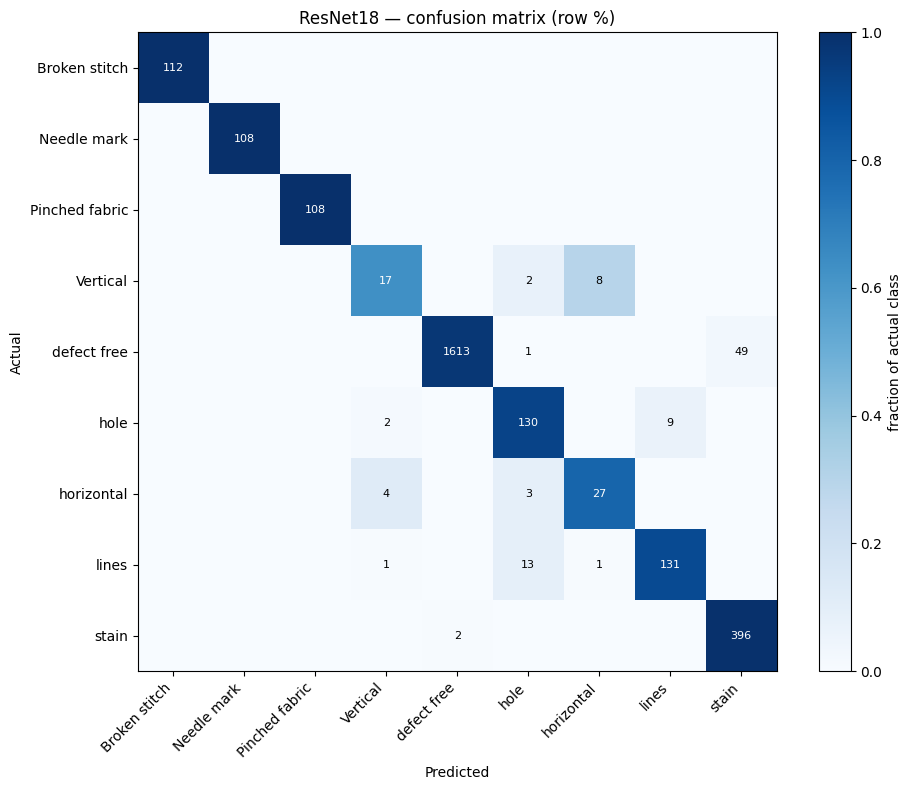

In [14]:
cm = confusion_matrix(oof_true, oof_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n_classes)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(n_classes)); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("ResNet18 — confusion matrix (row %)")

for i in range(n_classes):
    for j in range(n_classes):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm_pct[i, j] > 0.5 else "black")

plt.colorbar(im, label="fraction of actual class")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{MODEL_NAME}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Observations:** The matrix is now almost entirely diagonal, which is what a working classifier looks like.

**The baseline's biggest failure is gone.** Broken stitch, Needle mark and Pinched fabric are 112/112, 108/108 and 108/108 — not a single mistake between them. In the baseline, Broken stitch was called Needle mark 69 times out of 112.

**What is left is one small cluster of confusions:**

- **Vertical** (27) gets 17 right, with 8 called "horizontal" and 2 called "hole"
- **horizontal** (34) gets 27 right, with 4 called "Vertical"
- **hole** and **lines** trade a few between them — 13 lines called "hole", 9 holes called "lines"

So the remaining errors are all between defects that genuinely look alike: thin marks whose direction is hard to judge. The baseline confused defects that look nothing alike, which was a much more basic failure.

**The safety numbers are excellent.** Only **2 defective images out of 1,074 (0.2%)** are called "defect free", both stains. The baseline missed 10. And false alarms fell too, from 157 to **50 of 1,663 clean images (3.0%)**.

That both numbers improved together is worth noting. Usually catching more defects means more false alarms, and the two trade against each other. Here the model simply became better at the task, so it improved on both at once.

## 8. Did Transfer Learning Help?

**What:** Put the two models side by side.

**Why this is the point of the project.** Both were trained on the same images, the same folds, the same augmentation and the same class weights. The only difference is that ResNet18 started from a network already trained on a million photographs. Any gap between them is therefore attributable to that pretraining — which is the claim this project set out to test.

The safety-critical number is also included: how many defective rolls would be passed as clean fabric.

In [15]:
missed_defects = int(sum(cm[i, class_names.index("defect free")]
                         for i, c in enumerate(class_names) if c != "defect free"))
total_defects = int(sum(counts[c] for c in class_names if c != "defect free"))

comparison = pd.DataFrame([
    {"model": "Baseline CNN (from scratch)", "macro_f1": BASELINE["macro_f1"],
     "accuracy": BASELINE["accuracy"]},
    {"model": "ResNet18 (transfer learning)", "macro_f1": macro_f1, "accuracy": accuracy},
])
comparison["macro_f1_gain"] = comparison["macro_f1"] - BASELINE["macro_f1"]

print(comparison.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nDefects wrongly passed as 'defect free': {missed_defects} of {total_defects} "
      f"({missed_defects/total_defects:.1%})")
print(f"Baseline CNN missed 10 of 1,074 (0.9%) for comparison.")

                       model  macro_f1  accuracy  macro_f1_gain
 Baseline CNN (from scratch)     0.583     0.837          0.000
ResNet18 (transfer learning)     0.908     0.965          0.325

Defects wrongly passed as 'defect free': 2 of 1074 (0.2%)
Baseline CNN missed 10 of 1,074 (0.9%) for comparison.


**Observations:** **Transfer learning made a decisive difference.**

| | Baseline CNN | ResNet18 | Change |
|---|---:|---:|---:|
| Macro F1 | 0.583 | **0.908** | **+0.325** |
| Accuracy | 0.837 | 0.965 | +0.128 |
| Defects missed | 10 (0.9%) | **2 (0.2%)** | 5× fewer |
| Clean rolls wrongly flagged | 157 (9.4%) | 50 (3.0%) | 3× fewer |

Macro F1 rose by more than half, from 0.583 to 0.908.

Because everything else was held constant — the same images, the same folds, the same augmentation, the same class weights, the same number of epochs, the same seed — the only difference between these two rows is where the network started. One began from random numbers; the other began from a network already trained on a million photographs.

That is the claim this project set out to test, and the answer is clear.

For a factory, the practical result is that 2 defective rolls in every 1,074 would reach the customer instead of 10, while a third fewer good rolls get pulled aside for a needless second look.

## 9. Save the Model and Its Settings

**What:** Write out the results, and save the settings needed to reload the model later.

**A note on repository size.** Each ResNet18 fold is about 45 MB, so all five would add over 220 MB to the repository. Only **fold 0** is kept in git — enough to load the model and make predictions — while the other four are regenerated by re-running this notebook. The baseline CNN's weights are only 1.6 MB each, so all five of those are kept.

**Why the settings matter as much as the weights.** A saved model is a list of numbers; on its own it cannot be used. Anything making predictions later has to know which class each output position means, what size images to expect, and which normalisation values were applied. Saving those alongside the weights is what makes the model reusable — a prediction notebook can then load it in a few lines without repeating any training.

In [17]:
scores_df.to_csv(RESULTS_DIR / f"{MODEL_NAME}_fold_scores.csv", index=False)
history_df.to_csv(RESULTS_DIR / f"{MODEL_NAME}_history.csv", index=False)

pred_df = manifest.copy()
pred_df["predicted"] = [class_names[i] for i in oof_pred]
pred_df["correct"] = pred_df["predicted"] == pred_df["class"]
pred_df.to_csv(RESULTS_DIR / f"{MODEL_NAME}_predictions.csv", index=False)

summary = {
    "model": "ResNet18 (transfer learning)",
    "chosen_approach": best["name"],
    "freeze_backbone": BEST_CFG["freeze"],
    "learning_rate": BEST_CFG["lr"],
    "epochs": FINAL_EPOCHS,
    "n_images": int(len(manifest)),
    "n_classes": n_classes,
    "n_folds": int(manifest["fold"].nunique()),
    "macro_f1": float(macro_f1),
    "accuracy": float(accuracy),
    "per_class_recall": {c: float(r) for c, r in zip(class_names, recalls)},
    "baseline_cnn_macro_f1": BASELINE["macro_f1"],
    "missed_defects": missed_defects,
    "total_defects": total_defects,
}
json.dump(summary, open(RESULTS_DIR / f"{MODEL_NAME}_summary.json", "w"), indent=2)

model_config = {
    "architecture": "resnet18",
    "class_names": class_names,
    "img_size": IMG_SIZE,
    "normalize_mean": IMAGENET_MEAN,
    "normalize_std": IMAGENET_STD,
    "freeze_backbone": BEST_CFG["freeze"],
    "weight_files": [f"{MODEL_NAME}_fold{f}.pt" for f in sorted(manifest["fold"].unique())],
}
json.dump(model_config, open(MODELS_DIR / f"{MODEL_NAME}_config.json", "w"), indent=2)

ASSETS = Path("assets")
if ASSETS.exists():
    import shutil
    shutil.copy2(RESULTS_DIR / f"{MODEL_NAME}_confusion_matrix.png", ASSETS)
    print("Confusion matrix copied to assets/\n")

print("Results:", RESULTS_DIR)
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"   {f.name:40s} {f.stat().st_size/1024:8.1f} KB")
print("\nModels:", MODELS_DIR)
for f in sorted(MODELS_DIR.iterdir()):
    print(f"   {f.name:40s} {f.stat().st_size/1024:8.1f} KB")

Results: /content/outputs/resnet18
   resnet18_confusion_matrix.png                92.3 KB
   resnet18_experiments.csv                      0.3 KB
   resnet18_experiments.png                    142.3 KB
   resnet18_fold_scores.csv                      0.2 KB
   resnet18_history.csv                          7.7 KB
   resnet18_predictions.csv                    211.9 KB
   resnet18_summary.json                         0.7 KB

Models: /content/models
   resnet18_config.json                          0.5 KB
   resnet18_fold0.pt                         43754.5 KB
   resnet18_fold1.pt                         43754.5 KB
   resnet18_fold2.pt                         43754.5 KB
   resnet18_fold3.pt                         43754.5 KB
   resnet18_fold4.pt                         43754.5 KB


## 10. Summary

### What this notebook did

1. Loaded the same 2,737 images and the same five folds used by Notebook 03.
2. Compared **three ways** of adapting ResNet18 — frozen backbone, gentle fine-tuning, and aggressive fine-tuning — using a validation fold that played no part in the final score.
3. Trained the winning approach across all five folds, so every image was tested by a model that had never seen it.
4. **Saved the trained weights and the settings needed to reload them**, so predictions can be made later without retraining.
5. Compared the result directly against the baseline CNN, changing nothing except the model.

### Headline results

| Measure | Baseline CNN | ResNet18 |
|---|---|---|
| **Macro F1** (main metric) | 0.583 | **0.908** |
| Accuracy | 0.837 | 0.965 |
| **Rare-defect recall — Vertical** | 0.148 | 0.630 (range 0.33–0.83) |
| **Rare-defect recall — horizontal** | 0.676 | 0.794 (range 0.57–1.00) |
| Mean recall across rare classes | 0.558 | 0.892 |
| Defects passed as normal | 10 of 1,074 (0.9%) | **2 of 1,074 (0.2%)** |
| Clean rolls wrongly flagged | 157 of 1,663 (9.4%) | 50 of 1,663 (3.0%) |

**Chosen approach:** full fine-tuning at learning rate 0.0001, selected because it scored 0.908 on validation against 0.711 for a frozen backbone and 0.502 for fine-tuning at 0.001.

Three classes — Broken stitch, Needle mark and Pinched fabric — are now classified perfectly, in every fold. "Vertical" (27 images) remains the weakest at 0.630 recall and is quoted with its range, because with so few images a single figure would overstate what is known.

### Files produced

```
outputs/resnet18/
├── resnet18_summary.json          headline scores and per-class recall
├── resnet18_experiments.csv       the three approaches and their scores
├── resnet18_experiments.png       training curves for the comparison
├── resnet18_fold_scores.csv       score for each fold
├── resnet18_history.csv           loss and F1 after every epoch
├── resnet18_predictions.csv       the prediction for every image
└── resnet18_confusion_matrix.png  confusion matrix figure

models/
├── resnet18_fold0.pt … fold4.pt   trained weights, one per fold
└── resnet18_config.json           class names, image size, normalisation
```

### Decisions worth defending

- **Three approaches compared rather than one tried.** Whether to freeze the pretrained layers is a real choice with arguments on both sides, so it was measured rather than assumed.
- **A separate validation fold for choosing.** Selecting the approach on the test data would have inflated the final score. Fold 3 made the choice; fold 4 stayed out of it entirely and acts as a clean check.
- **Everything except the model held constant.** Same folds, same augmentation, same class weights, same metrics, same seed — so the comparison isolates the effect of pretraining.
- **A deliberately bad configuration included.** Fine-tuning at lr 0.001 was expected to damage the pretrained features. Testing it demonstrates *why* the chosen learning rate is right, rather than merely asserting it.
- **Weights and settings saved together.** Weights alone cannot be used; the class order, image size and normalisation values are what make them reloadable.

### Honest limitations

- The approach was chosen using fold 3, which also appears in the final cross-validation, so the headline figure is slightly optimistic. Fold 4's score is reported separately as a clean comparison.
- "Vertical" (27 images) and "horizontal" (34) remain very small. Their per-class scores carry real uncertainty no matter which model is used.
- The dataset combines several source collections, so some source-related bias may remain, as recorded in Notebook 01.

### Next: prediction on new images

With the weights and settings saved, a prediction notebook can load the model and classify a fabric image it has never seen — the end-to-end demo the project set out to build.